In [76]:
!pip install kagglehub

In [77]:
import kagglehub

path = kagglehub.dataset_download(
    "abdallahalidev/plantvillage-dataset"
)

print("Dataset Path:", path)


Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset Path: /kaggle/input/plantvillage-dataset


In [78]:
import os

print(os.listdir(path))

['plantvillage dataset']


In [79]:
dataset_path = os.path.join(path, "plantvillage dataset")

In [80]:
print(os.listdir(dataset_path)[:5])

['segmented', 'grayscale', 'color']


In [81]:
dataset_path = os.path.join(
    path,
    "plantvillage dataset",
    "color"
)

In [82]:
print(os.listdir(dataset_path)[:5])

['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy']


In [83]:
import cv2
import numpy as np
import os

images = []
labels = []

folders = os.listdir(dataset_path)

# Use only first 5 classes initially
folders = folders[:5]

for folder in folders:

    folder_path = os.path.join(dataset_path, folder)

    count = 0

    for img_name in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path)

        if img is not None:

            # Resize image
            img = cv2.resize(img, (128,128))

            images.append(img)

            labels.append(folder)

            count += 1

        # Limit images per class
        if count == 200:
            break

print("Images Loaded:", len(images))

Images Loaded: 1000


In [84]:
X = np.array(images)
y = np.array(labels)

print(X.shape)
print(y.shape)

(1000, 128, 128, 3)
(1000,)


In [85]:
X = X / 255.0

In [86]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(y[:10])

[3 3 3 3 3 3 3 3 3 3]


In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [88]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [89]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

model = Sequential([

    # Convolution Layer 1
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    # Max Pooling
    MaxPooling2D((2,2)),

    # Convolution Layer 2
    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    # Max Pooling
    MaxPooling2D((2,2)),

    # Flatten Layer
    Flatten(),

    # Dense Layer
    Dense(128, activation='relu'),

    # Output Layer
    Dense(len(folders), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [90]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,965 (28.20 MB)

 Trainable params: 7,392,965 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [91]:
from tensorflow.keras.layers import Dropout

In [92]:
model = Sequential([

    Conv2D(32, (3,3),
           activation='relu',
           input_shape=(128,128,3)),

    MaxPooling2D((2,2)),

    Conv2D(64, (3,3),
           activation='relu'),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(len(folders), activation='softmax')
])

In [93]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3
)

In [94]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [95]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.3775 - loss: 1.5491 - val_accuracy: 0.6450 - val_loss: 0.8596
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7050 - loss: 0.7305 - val_accuracy: 0.8900 - val_loss: 0.3527
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8363 - loss: 0.4263 - val_accuracy: 0.8900 - val_loss: 0.3357
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8612 - loss: 0.3715 - val_accuracy: 0.9600 - val_loss: 0.1617
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9350 - loss: 0.2052 - val_accuracy: 0.9550 - val_loss: 0.1462
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9100 - loss: 0.2691 - val_accuracy: 0.9550 - val_loss: 0.1671
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9325 - loss: 0.2137 - val_accuracy: 0.9350 - val_loss: 0.1836
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9538 - loss: 0.1552 - val_accuracy: 0.9450 - v

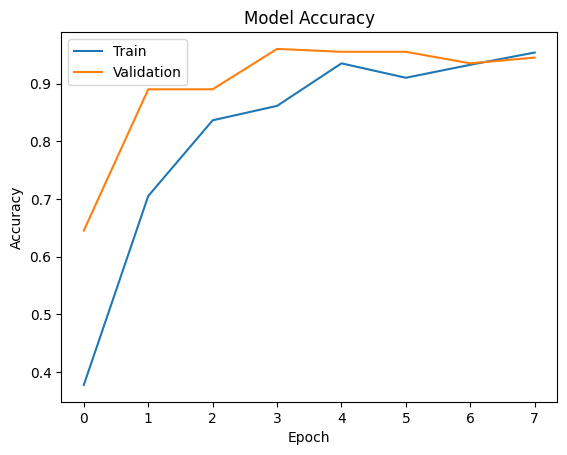

In [98]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

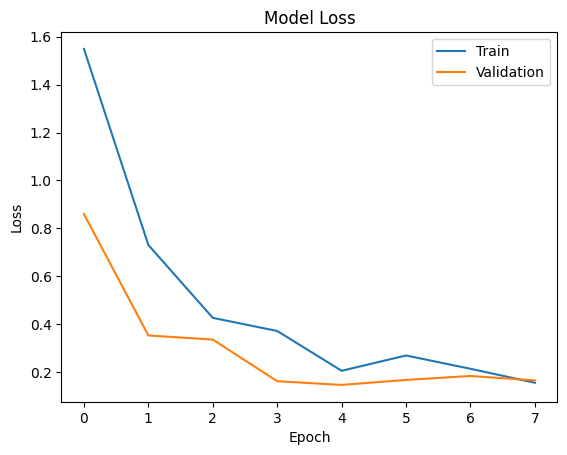

In [99]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

In [100]:
model.save("plant_disease_model.h5")

In [101]:
model.save("plant_disease_model.keras")

In [102]:
from google.colab import files

files.download("plant_disease_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [106]:
import tensorflow as tf

print(tf.__version__)

2.20.0
